In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

In [73]:
country_names = {
    'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria', 'CY': 'Cyprus',
    'CZ': 'Czechia', 'DE': 'Germany', 'DK': 'Denmark', 'EE': 'Estonia',
    'EL': 'Greece', 'ES': 'Spain', 'FI': 'Finland', 'FR': 'France',
    'HR': 'Croatia', 'HU': 'Hungary', 'IE': 'Ireland', 'IS': 'Iceland',
    'IT': 'Italy', 'LI': 'Liechtenstein', 'LT': 'Lithuania', 'LU': 'Luxembourg',
    'LV': 'Latvia', 'MT': 'Malta', 'NL': 'Netherlands', 'NO': 'Norway',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden',
    'SI': 'Slovenia', 'SK': 'Slovakia'
}

df_cases = raw data
df_cases_filtered_20to22 = data with correct dates
df_cases_clean = clean data

In [74]:
df_cases_original = pd.read_csv('1.COVID-19_daily_number_of_new_cases_and_deaths.csv')
df_vax_original = pd.read_csv('2.COVID-19_vaccination.csv')
df_hosp_original = pd.read_csv('3.COVID-19_hospital_and_ICU_admission_rates.csv')

df_cases = df_cases_original.copy()
df_vax = df_vax_original.copy()
df_hosp = df_hosp_original.copy()
# creating datetime objects and filtering for 2020-2022
df_cases['dateRep'] = pd.to_datetime(df_cases['dateRep'], format='%d/%m/%Y')
# Filter the cases dataset to include only data from 2020 to 2022
df_cases_clean = df_cases[(df_cases['dateRep'].dt.year >= 2020) & (df_cases['dateRep'].dt.year <= 2022)].copy()

In [75]:
display(df_cases.head())

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2020,continentExp
0,2022-10-23,23,10,2022,3557.0,0.0,Austria,AT,AUT,8901064,Europe
1,2022-10-22,22,10,2022,5494.0,4.0,Austria,AT,AUT,8901064,Europe
2,2022-10-21,21,10,2022,7776.0,4.0,Austria,AT,AUT,8901064,Europe
3,2022-10-20,20,10,2022,8221.0,6.0,Austria,AT,AUT,8901064,Europe
4,2022-10-19,19,10,2022,10007.0,8.0,Austria,AT,AUT,8901064,Europe


Preprocessing/ datacleaning



--- Datamängdens storlek (Rader, Kolumner) ---
Cases Data: (28729, 11)
Vaccine Data: (681330, 18)
Hospital Data: (25100, 7)

--- Saknade värden i Cases Data (Topp 5) ---
deaths     292
cases       93
dateRep      0
day          0
month        0
dtype: int64 

--- Datatyper i Cases Data ---
dateRep                    datetime64[us]
day                                 int64
month                               int64
year                                int64
cases                             float64
deaths                            float64
countriesAndTerritories               str
geoId                                 str
countryterritoryCode                  str
popData2020                         int64
continentExp                          str
dtype: object 



,cases,deaths,popData2020
count,28636.000000,28437.000000,2.872900e+04
mean,6088.425129,40.866160,1.534803e+07
std,21455.994469,128.729388,2.142396e+07
min,-348846.000000,-217.000000,3.874700e+04
25%,111.000000,0.000000,2.095861e+06
50%,705.000000,5.000000,6.951482e+06
75%,3483.250000,31.000000,1.152244e+07
max,501635.000000,13743.000000,8.316671e+07


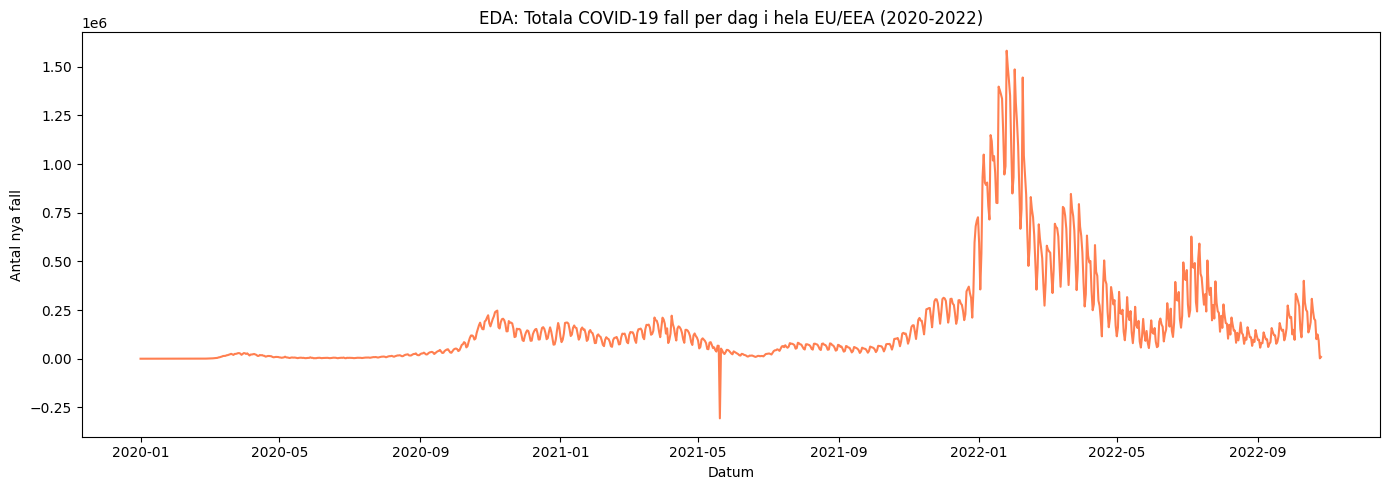

In [76]:
# --- EXPLORATORY DATA ANALYSIS (EDA) ---

# 1. Hur stor är vår data? (Antal rader och kolumner)
print("--- Datamängdens storlek (Rader, Kolumner) ---")
print(f"Cases Data: {df_cases.shape}")
print(f"Vaccine Data: {df_vax.shape}")
print(f"Hospital Data: {df_hosp.shape}\n")

# 2. Saknas det värden (Missing values/NaNs)?
# Detta är avgörande för att veta vilka kolumner vi kan lita på
print("--- Saknade värden i Cases Data (Topp 5) ---")
print(df_cases.isna().sum().nlargest(5), "\n")

# 3. Vilka datatyper har vi? (Är siffror faktiskt siffror och inte text?)
print("--- Datatyper i Cases Data ---")
print(df_cases.dtypes, "\n")

# 4. Snabb statistisk överblick (Medelvärde, min, max) för numeriska kolumner
display(df_cases[['cases', 'deaths', 'popData2020']].describe())

# --- SNABB VISUALISERING FÖR FÖRSTÅELSE ---
# Vi ritar upp den totala trenden för hela EU/EEA (alla länder sammanslagna) över tid
plt.figure(figsize=(14, 5))
global_trend = df_cases.groupby('dateRep')['cases'].sum().reset_index()

sns.lineplot(data=global_trend, x='dateRep', y='cases', color='coral')
plt.title('EDA: Totala COVID-19 fall per dag i hela EU/EEA (2020-2022)')
plt.ylabel('Antal nya fall')
plt.xlabel('Datum')
plt.tight_layout()
plt.show()

In [77]:
#check for duplicates
print(f"Duplicate rows in cases dataset: {df_cases.duplicated().sum()}")
#check for negative values in cases
print(f"Negative values in cases dataset: {df_cases_clean[df_cases_clean['cases'] < 0].shape[0]}")
print(f"Rows with negative deaths: {df_cases_clean[df_cases_clean['deaths'] < 0].shape[0]}")

Duplicate rows in cases dataset: 0
Negative values in cases dataset: 14
Rows with negative deaths: 17


In [78]:
#check for duplicates for all datasets
print(f"Duplicate rows in cases dataset: {df_cases.duplicated().sum()}")
print(f"Duplicate rows in vaccine dataset: {df_vax.duplicated().sum()}")
print(f"Duplicate rows in hospital dataset: {df_hosp.duplicated().sum()}")

#check for negative values
print(f"Negative values in cases dataset: {df_cases_clean[df_cases_clean['cases'] < 0].shape[0]}")
print(f"Rows with negative deaths: {df_cases_clean[df_cases_clean['deaths'] < 0].shape[0]}")
# 

Duplicate rows in cases dataset: 0
Duplicate rows in vaccine dataset: 0
Duplicate rows in hospital dataset: 0
Negative values in cases dataset: 14
Rows with negative deaths: 17


In [79]:
# =====================================================================
# DATA IMPORT, CLEANING & DEDUPLICATION
# =====================================================================

# 3. CLEANING & DEDUPLICATION (Applied to working copies)
df_cases = df_cases.drop_duplicates()
df_vax = df_vax.drop_duplicates()
df_hosp = df_hosp.drop_duplicates()

print("Dubbletter borttagna och datatvätt påbörjad...")

# --- CLEANING DATASET 1: Cases & Deaths ---
df_cases_clean = df_cases.dropna(subset=['cases', 'deaths', 'popData2020']).copy()
df_cases_clean = df_cases_clean[(df_cases_clean['cases'] >= 0) & (df_cases_clean['deaths'] >= 0)]

# --- CLEANING DATASET 2: Vaccination ---
df_vax['Population'] = pd.to_numeric(df_vax['Population'], errors='coerce')
df_vax['FirstDose'] = pd.to_numeric(df_vax['FirstDose'], errors='coerce')
df_vax['SecondDose'] = pd.to_numeric(df_vax['SecondDose'], errors='coerce')
df_vax['FirstDoseRefused'] = pd.to_numeric(df_vax['FirstDoseRefused'], errors='coerce')

df_vax_clean = df_vax.dropna(subset=['Population', 'TargetGroup']).copy()
df_vax_clean = df_vax_clean[df_vax_clean['TargetGroup'] != 'ALL']

# --- CLEANING DATASET 3: Hospital & ICU ---
df_hosp_clean = df_hosp.dropna(subset=['value']).copy()
df_hosp_clean['value'] = pd.to_numeric(df_hosp_clean['value'], errors='coerce').fillna(0)
# Filtrera (använd .str.contains för att vara mer flexibel med versaler/gemener)
df_hosp_clean = df_hosp_clean[df_hosp_clean['indicator'].str.contains('hospital', case=False, na=False)]

print("All data är nu tvättad, deduplicerad och redo för analys!")

Dubbletter borttagna och datatvätt påbörjad...
All data är nu tvättad, deduplicerad och redo för analys!


In [81]:
print(f"Antal rader med negativa fall: {(df_cases_clean['cases'] < 0).sum()}")
print(f"Antal rader med negativa dödsfall: {(df_cases_clean['deaths'] < 0).sum()}")

Antal rader med negativa fall: 0
Antal rader med negativa dödsfall: 0


Q1:

Top 10 countries with the most absolute number of cases:
1. France: 36952159
2. Germany: 35287690
3. Italy: 23359251
4. Spain: 13564823
5. Netherlands: 8494705
6. Poland: 6189562
7. Portugal: 5514482
8. Austria: 5402162
9. Greece: 5138059
10. Belgium: 4597870
Top 10 countries based on total cases per 100 000 people (2020-2022):
1. Austria: 60691
2. France: 54890
3. Portugal: 53559
4. Netherlands: 48798
5. Greece: 47936
6. Germany: 42430
7. Belgium: 39903
8. Italy: 39166
9. Spain: 28658
10. Poland: 16306


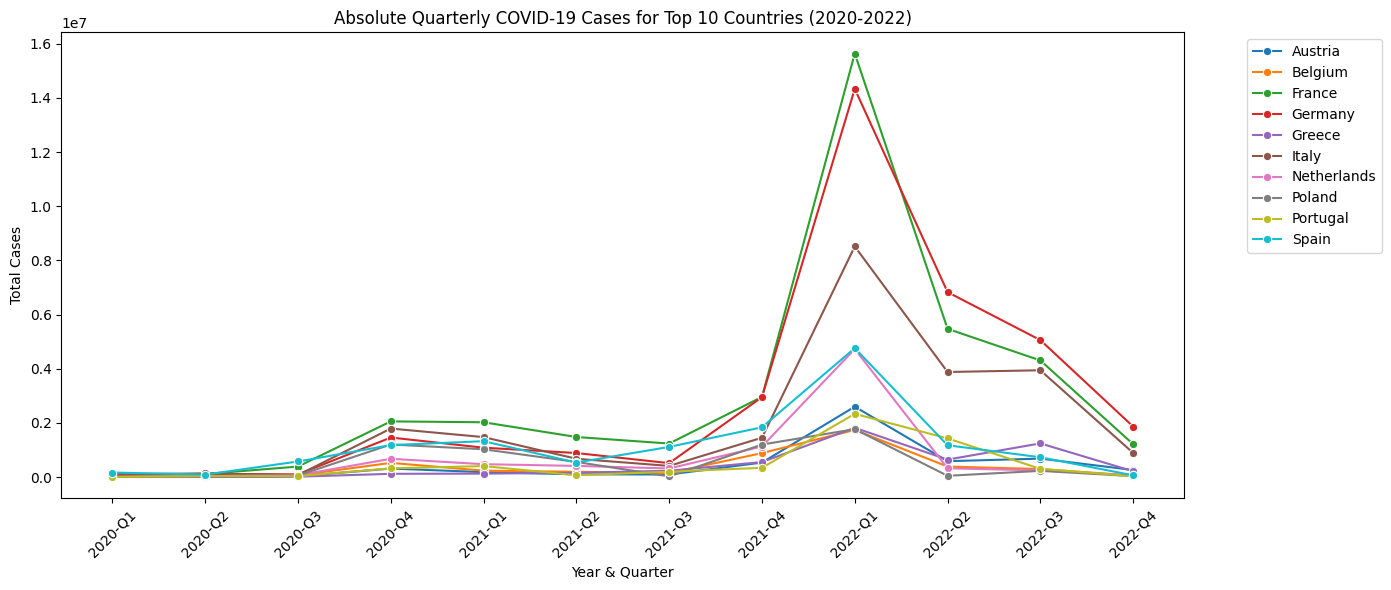

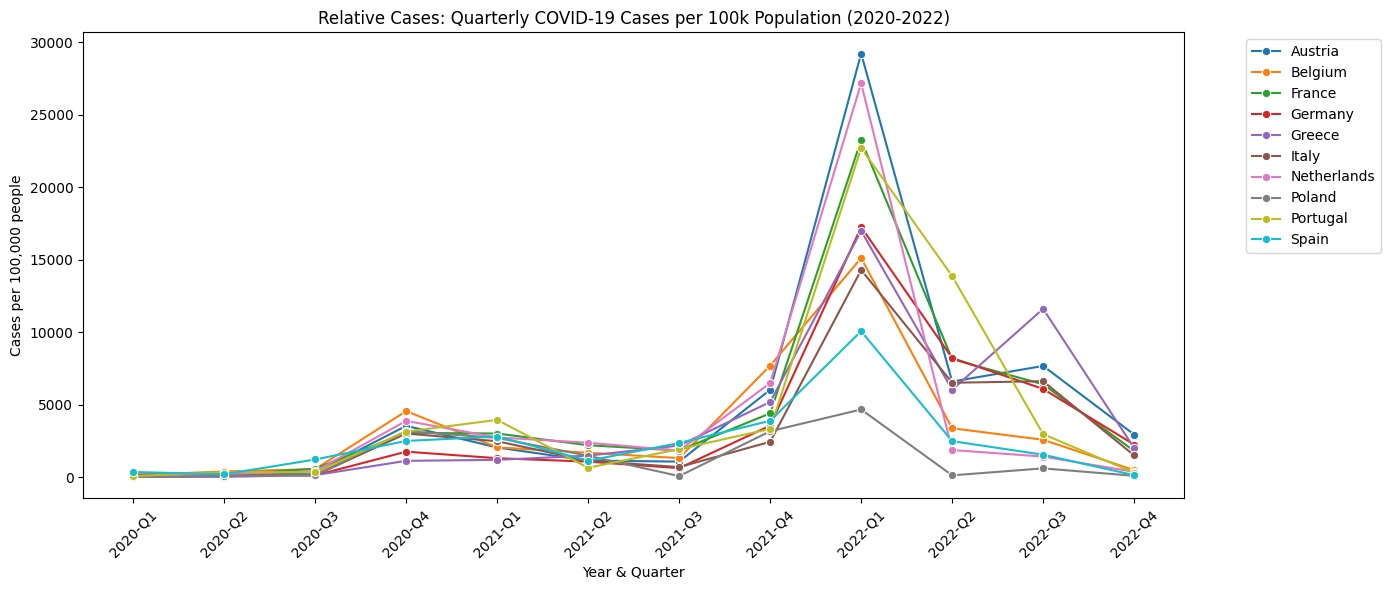

In [82]:


# 3. Create 'Year', 'Quarter', and a combined 'Year_Quarter' column for plotting
df_cases_clean['Year'] = df_cases_clean['dateRep'].dt.year
df_cases_clean['Quarter'] = df_cases_clean['dateRep'].dt.quarter
df_cases_clean['Year_Quarter'] = df_cases_clean['Year'].astype(str) + "-Q" + df_cases_clean['Quarter'].astype(str)

# 4. Find the Top 10 countries by absolute number of cases
top_10_cases = (
    df_cases_clean.groupby('countriesAndTerritories')['cases']
    .sum()
    .nlargest(10)
 )
top_10_countries = top_10_cases.index.tolist()
print("Top 10 countries with the most absolute number of cases:")
for i, (country, total_cases) in enumerate(top_10_cases.items(), 1):
    print(f"{i}. {country}: {int(total_cases)}")

# 5. Filter the dataset to ONLY include these top 10 countries
df_top10 = df_cases_clean[df_cases_clean['countriesAndTerritories'].isin(top_10_countries)]

# 6. Group the data by Country and Year_Quarter to get the sum of cases per quarter
quarterly_cases = df_top10.groupby(['countriesAndTerritories', 'Year_Quarter'])['cases'].sum().reset_index()

# 7. Get the population for each country to calculate relative numbers
# We use .max() to grab the single population value without summing duplicates
country_pops = df_top10.groupby('countriesAndTerritories')['popData2020'].max().reset_index()

# Merge the population data into our quarterly cases data
quarterly_cases = quarterly_cases.merge(country_pops, on='countriesAndTerritories')

# 8. Calculate Incidence Rate: Cases per 100,000 people
quarterly_cases['cases_per_100k'] = (quarterly_cases['cases'] / quarterly_cases['popData2020']) * 100000
# Vi grupperar på länderna för hela perioden för att få en total rankning att printa
top10_total = df_top10.groupby('countriesAndTerritories').agg({'cases': 'sum', 'popData2020': 'max'}).reset_index()
top10_total['total_cases_per_100k'] = (top10_total['cases'] / top10_total['popData2020']) * 100000
top10_total = top10_total.sort_values(by='total_cases_per_100k', ascending=False)

print("Top 10 countries based on total cases per 100 000 people (2020-2022):")
for i, (index, row) in enumerate(top10_total.iterrows(), 1):
    print(f"{i}. {row['countriesAndTerritories']}: {int(row['total_cases_per_100k'])}")
# --- VISUALIZATION ---

# Plot 1: Absolute Cases
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_cases, x='Year_Quarter', y='cases', hue='countriesAndTerritories', marker='o')
plt.title('Absolute Quarterly COVID-19 Cases for Top 10 Countries (2020-2022)')
plt.ylabel('Total Cases')
plt.xlabel('Year & Quarter')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Relative Cases (per 100k population)
plt.figure(figsize=(14, 6))
sns.lineplot(data=quarterly_cases, x='Year_Quarter', y='cases_per_100k', hue='countriesAndTerritories', marker='o')
plt.title('Relative Cases: Quarterly COVID-19 Cases per 100k Population (2020-2022)')
plt.ylabel('Cases per 100,000 people')
plt.xlabel('Year & Quarter')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Q2:

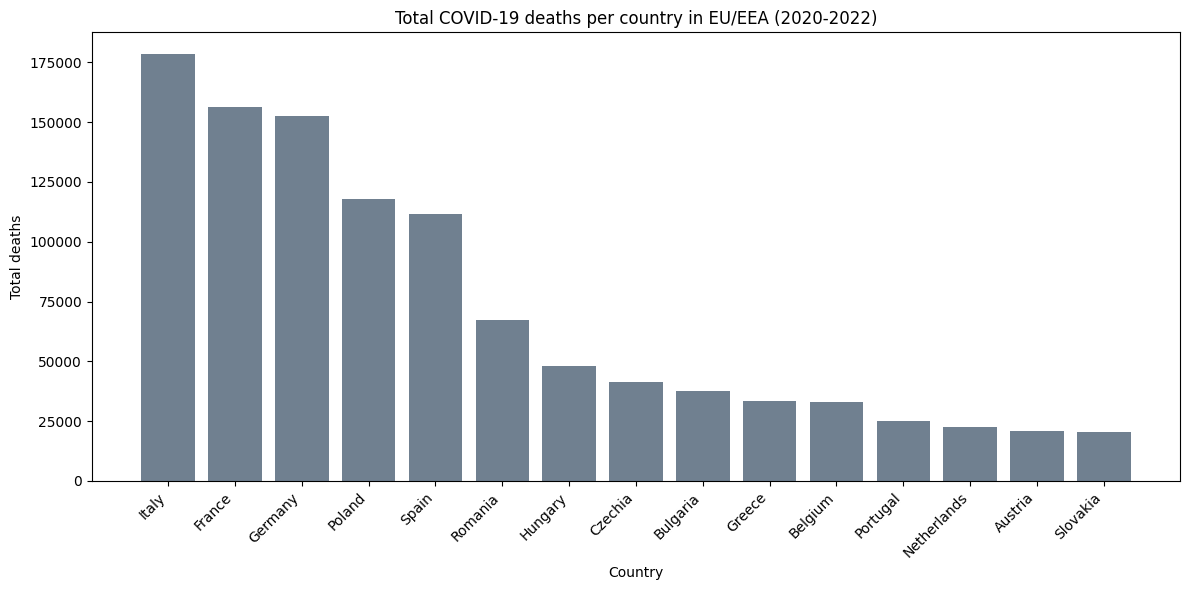

In [83]:
import plotly.express as px

# 1. Aggregera datan (precis som innan)
map_data = df_cases_clean.groupby(['countriesAndTerritories', 'countryterritoryCode', 'year'])[['cases', 'deaths']].sum().reset_index()

# --- NYTT: Hitta det absoluta maxvardet for hela perioden for att lasa fargskalan ---
max_cases = map_data['cases'].max()
max_deaths = map_data['deaths'].max()

# 2. Skapa karta for FALL (Cases)
fig_cases = px.choropleth(
    map_data,
    locations="countryterritoryCode",
    color="cases",
    hover_name="countriesAndTerritories",
    animation_frame="year",
    color_continuous_scale="Reds",
    range_color=[0, max_cases],       # <-- DETTA LASER FARGSKALAN
    scope="europe",
    title="Total COVID-19 Cases per Country in EU/EEA (2020-2022)"
 )

# 3. Skapa karta for DODSFALL (Deaths)
fig_deaths = px.choropleth(
    map_data,
    locations="countryterritoryCode",
    color="deaths",
    hover_name="countriesAndTerritories",
    animation_frame="year",
    color_continuous_scale="Greys",
    range_color=[0, max_deaths],      # <-- DETTA LASER FARGSKALAN
    scope="europe",
    title="Total COVID-19 Deaths per Country in EU/EEA (2020-2022)"
 )

# 4. Skapa karta for DODSFALL PER 100K (Death Rate) with matplotlib
map_data['death_rate_per_100k'] = (map_data['deaths'] / map_data['cases']) * 100000

fig_cases.show()
fig_deaths.show()

# 5. Plot total deaths med matplotlib
total_deaths = (
    map_data.groupby('countriesAndTerritories')['deaths']
    .sum()
    .sort_values(ascending=False)
    .head(15)
 )

plt.figure(figsize=(12, 6))
plt.bar(total_deaths.index.str.replace('_', ' '), total_deaths.values, color='slategray')
plt.title('Total COVID-19 deaths per country in EU/EEA (2020-2022)')
plt.ylabel('Total deaths')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Q3.

Understand the data

In [84]:
# Kolla vilka kolumner vi har att jobba med
print(df_vax.columns)

# Titta på de första raderna för att förstå strukturen
display(df_vax.head())

Index(['YearWeekISO', 'ReportingCountry', 'Denominator', 'NumberDosesReceived',
       'NumberDosesExported', 'FirstDose', 'FirstDoseRefused', 'SecondDose',
       'DoseAdditional1', 'DoseAdditional2', 'DoseAdditional3',
       'DoseAdditional4', 'DoseAdditional5', 'UnknownDose', 'Region',
       'TargetGroup', 'Vaccine', 'Population'],
      dtype='str')


,YearWeekISO,ReportingCountry,Denominator,NumberDosesReceived,NumberDosesExported,FirstDose,FirstDoseRefused,SecondDose,DoseAdditional1,DoseAdditional2,DoseAdditional3,DoseAdditional4,DoseAdditional5,UnknownDose,Region,TargetGroup,Vaccine,Population
0,2021-W05,AT,423433.0,0.0,0.0,0,NaN,0,0,0,0,0,0,0,AT,Age10_14,AZ,8932664
1,2023-W10,AT,1543886.0,0.0,0.0,0,NaN,1,0,0,0,0,0,0,AT,Age<18,NVXD,8978929
2,2023-W10,AT,1047888.0,0.0,0.0,1,NaN,0,0,1,0,0,0,0,AT,Age60_69,NVXD,8978929
3,2023-W10,AT,258398.0,0.0,0.0,0,NaN,0,0,0,0,0,0,0,AT,Age15_17,MODBA.1,8978929
4,2023-W10,AT,7388778.0,0.0,0.0,3,NaN,1,4,80,53,0,0,0,AT,ALL,MOD,8978929


In [85]:
import pandas as pd

# 1. Define columns that represent administered doses
# Note: 'FirstDoseRefused' is explicitly excluded.
dose_columns = [
    'FirstDose', 'SecondDose', 'DoseAdditional1', 'DoseAdditional2', 
    'DoseAdditional3', 'DoseAdditional4', 'DoseAdditional5', 'UnknownDose'
]

# Fill NaN values with 0 to allow proper summation
df_vax[dose_columns] = df_vax[dose_columns].fillna(0)

# Calculate total doses administered per row
df_vax['TotalDoses'] = df_vax[dose_columns].sum(axis=1)

# 2. Find the Top 3 vaccines across the entire EU/EEA
eu_top_vaccines = df_vax.groupby('Vaccine')['TotalDoses'].sum().nlargest(3).reset_index()
top_3_eu_list = eu_top_vaccines['Vaccine'].tolist()


print("TOP 3 MOST POPULAR VACCINES ACROSS EU/EEA:")

for i, row in eu_top_vaccines.iterrows():
    print(f"{i+1}. {row['Vaccine']}: {int(row['TotalDoses']):,} doses")

# 3. Check popularity at the country level and find exceptions
country_vax = df_vax.groupby(['ReportingCountry', 'Vaccine'])['TotalDoses'].sum().reset_index()

exceptions = []


print("CHECKING COUNTRY EXCEPTIONS...")


# Loop through each unique country
for country in country_vax['ReportingCountry'].unique():
    # Get data for the specific country
    country_data = country_vax[country_vax['ReportingCountry'] == country]
    
    # Sort by total doses and get the Top 3 vaccines for this country
    country_top_3 = country_data.sort_values(by='TotalDoses', ascending=False).head(3)['Vaccine'].tolist()
    
    # Check if the country's Top 3 matches the EU's Top 3 (using set to ignore order)
    if set(country_top_3) != set(top_3_eu_list):
        exceptions.append((country, country_top_3))

# Print the results for exceptions
if not exceptions:
    print("All countries share the exact same Top 3 vaccines as the EU/EEA overall.")
else:
    print(f"Found {len(exceptions)} exception(s) where the country's Top 3 differs from the EU average:\n")
    for country, vax_list in exceptions:
        print(f"- {country}'s Top 3: {', '.join(vax_list)}")

TOP 3 MOST POPULAR VACCINES ACROSS EU/EEA:
1. COM: 1,239,822,614 doses
2. UNK: 862,532,787 doses
3. MOD: 296,957,284 doses
CHECKING COUNTRY EXCEPTIONS...
Found 28 exception(s) where the country's Top 3 differs from the EU average:

- AT's Top 3: COM, MOD, AZ
- BE's Top 3: COM, MOD, COMBA.1
- BG's Top 3: COM, JANSS, MOD
- CY's Top 3: COM, AZ, MOD
- CZ's Top 3: COM, MOD, AZ
- DE's Top 3: UNK
- DK's Top 3: COM, MOD, COMBA.4-5
- EE's Top 3: COM, AZ, MOD
- EL's Top 3: COM, MOD, AZ
- ES's Top 3: COM, MOD, AZ
- HR's Top 3: COM, AZ, MOD
- HU's Top 3: COM, BECNBG, SPU
- IE's Top 3: COM, MOD, AZ
- IS's Top 3: COM, AZ, MOD
- IT's Top 3: COM, MOD, AZ
- LI's Top 3: MOD, COM, MODBA.1
- LT's Top 3: COM, AZ, MOD
- LU's Top 3: COM, MOD, AZ
- LV's Top 3: COM, MOD, JANSS
- MT's Top 3: COM, MOD, AZ
- NL's Top 3: COM, MOD, AZ
- NO's Top 3: COM, MOD, COMBA.4-5
- PL's Top 3: COM, AZ, MOD
- PT's Top 3: COM, MOD, AZ
- RO's Top 3: COM, JANSS, MOD
- SE's Top 3: COM, MOD, AZ
- SI's Top 3: COM, AZ, MOD
- SK's Top 

Unlike the overall EU average, none of the individual countries have 'Unknown' (UNK) in their top three, with the sole exception of Germany. Germany only reported 'Unknown' vaccine brands to the ECDC, which heavily skews the total EU data.

Q4:

In [86]:
import pandas as pd

# 1. Filter out the aggregate 'ALL' target group so it doesn't skew the results
df_vax_targets = df_vax[df_vax['TargetGroup'] != 'ALL'].copy()

# 2. Filter the dataset to ONLY include the Top 3 EU vaccines from Question 3
# (This assumes the variable top_3_eu_list is still in memory from the last cell)
df_top_vaccines = df_vax_targets[df_vax_targets['Vaccine'].isin(top_3_eu_list)]

# 3. Group by Country, Vaccine, and Target Group, then sum the total doses
target_group_doses = df_top_vaccines.groupby(
    ['ReportingCountry', 'Vaccine', 'TargetGroup']
)['TotalDoses'].sum().reset_index()

# 4. Find the Target Group that received the highest number of doses for each combination
# Sort by doses (descending), then drop duplicates keeping the first (highest) row
main_target_groups = target_group_doses.sort_values(
    by=['ReportingCountry', 'Vaccine', 'TotalDoses'], 
    ascending=[True, True, False]
)
main_target_groups = main_target_groups.drop_duplicates(subset=['ReportingCountry', 'Vaccine'], keep='first')

# 5. Create a clean Pivot Table for easy reading and reporting
pivot_targets = main_target_groups.pivot(
    index='ReportingCountry', 
    columns='Vaccine', 
    values='TargetGroup'
)

# Fill any missing values with a string indicating no data
pivot_targets = pivot_targets.fillna("No Data")

print("MAIN TARGET GROUPS FOR THE TOP 3 VACCINES PER COUNTRY:")
display(pivot_targets)

MAIN TARGET GROUPS FOR THE TOP 3 VACCINES PER COUNTRY:


Vaccine,COM,MOD,UNK
ReportingCountry,,,
AT,Age25_49,Age25_49,Age25_49
BE,Age25_49,Age25_49,No Data
BG,Age25_49,Age25_49,No Data
CY,Age25_49,Age25_49,No Data
CZ,Age25_49,Age25_49,No Data
DE,No Data,No Data,1_Age<60
DK,Age25_49,Age25_49,No Data
EE,Age25_49,Age25_49,No Data
EL,1_Age<60,1_Age<60,No Data


Q5:

TOP 5 MOST SKEPTICAL COUNTRIES (FIRST DOSE REFUSED):


,ReportingCountry,FirstDoseRefused
15,IS,581.0
0,AT,0.0
2,BG,0.0
3,CY,0.0
4,CZ,0.0



HOSPITALIZATION LEVELS (TOTAL SUM OF REPORTED VALUES):


,country,value
23,Spain,4.023601e+06
20,Romania,3.408840e+06
6,France,2.841670e+06
4,Czechia,2.118721e+06
1,Belgium,2.023928e+06
0,Austria,1.205130e+06
21,Slovakia,1.126068e+06
2,Bulgaria,4.011940e+05
15,Lithuania,3.929960e+05
22,Slovenia,3.672351e+05


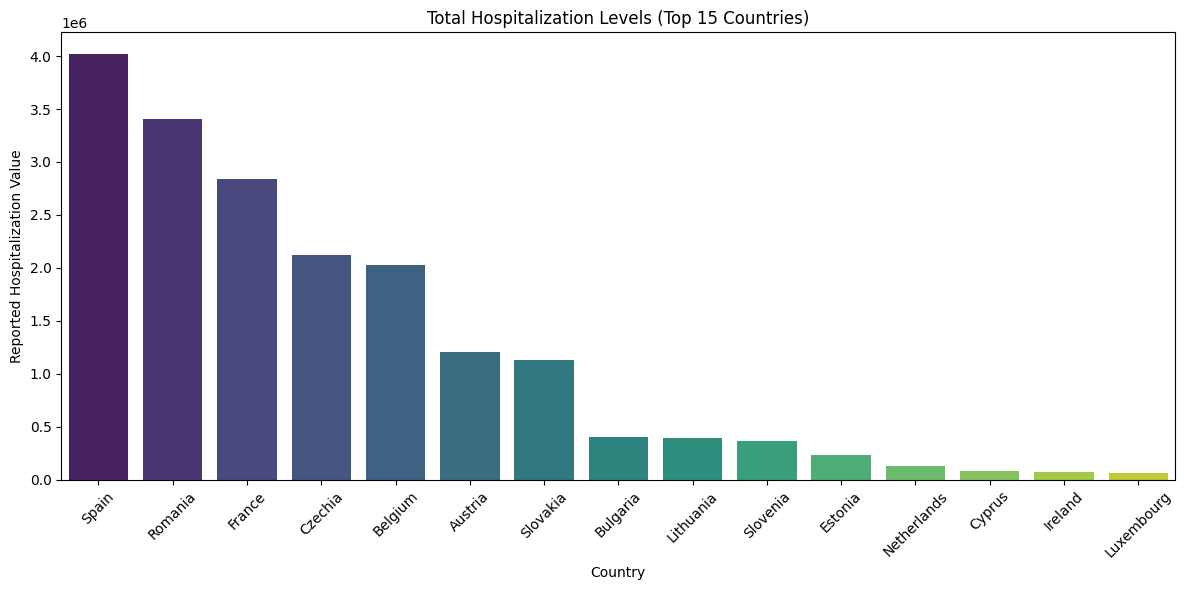

In [87]:
# =====================================================================
# PART 1: IDENTIFY THE MOST SKEPTICAL COUNTRIES (VACCINE REFUSALS)
# =====================================================================

# 1. Convert 'FirstDoseRefused' to numeric (just in case it's stored as strings)
df_vax['FirstDoseRefused'] = pd.to_numeric(df_vax['FirstDoseRefused'], errors='coerce').fillna(0)

# 2. Group by country and sum the total number of refused first doses
skepticism_df = df_vax.groupby('ReportingCountry')['FirstDoseRefused'].sum().reset_index()

# 3. Sort to find the countries with the highest number of refusals
skepticism_df = skepticism_df.sort_values(by='FirstDoseRefused', ascending=False)

print("="*50)
print("TOP 5 MOST SKEPTICAL COUNTRIES (FIRST DOSE REFUSED):")
print("="*50)
display(skepticism_df.head(5))

# Save the top 3 most skeptical countries for the next part
top_skeptics = skepticism_df.head(3)['ReportingCountry'].tolist()

# =====================================================================
# PART 2: IMPACT ON HOSPITALIZATION LEVELS
# =====================================================================

# 4. Load the hospital dataset (Ensure the file is in your directory)
# Using the exact filename provided in the assignment description
df_hosp = pd.read_csv('3.COVID-19_hospital_and_ICU_admission_rates.csv')

# 5. Filter for Hospital Admissions/Occupancy indicators
# Note: ECDC uses various indicators. We look for ones containing 'hospital'
df_hosp_filtered = df_hosp[df_hosp['indicator'].str.contains('hospital', case=False, na=False)]

# 6. Group by country to get the total/average hospitalization levels
hosp_summary = df_hosp_filtered.groupby('country')['value'].sum().reset_index()
hosp_summary = hosp_summary.sort_values(by='value', ascending=False)

print("\n" + "="*50)
print("HOSPITALIZATION LEVELS (TOTAL SUM OF REPORTED VALUES):")
print("="*50)
display(hosp_summary.head(10))

# 7. Visualization: Compare Hospitalization vs Skepticism (Optional but recommended for the report)
# We merge the two datasets to plot them together. 
# Note: We need to ensure country codes/names match. df_vax uses 2-letter codes, 
# while df_hosp often uses full names. We might need a quick mapping if they don't align perfectly.

# Assuming we just want to highlight the top skeptics in a plot for the report:
plt.figure(figsize=(12, 6))
sns.barplot(data=hosp_summary.head(15), x='country', y='value', hue='country', palette='viridis', legend=False)
plt.title('Total Hospitalization Levels (Top 15 Countries)')
plt.xticks(rotation=45)
plt.ylabel('Reported Hospitalization Value')
plt.xlabel('Country')
plt.tight_layout()
plt.show()

FirstDoseRefused bad column quality, only Iceland recorded this while the rest reported zero

TOP 5 LEAST VACCINATED COUNTRIES (PROXY FOR SKEPTICISM):
1. Bulgaria: 31.4% of the population
2. Slovakia: 52.0% of the population
3. Croatia: 59.5% of the population
4. Slovenia: 59.6% of the population
5. Estonia: 65.3% of the population


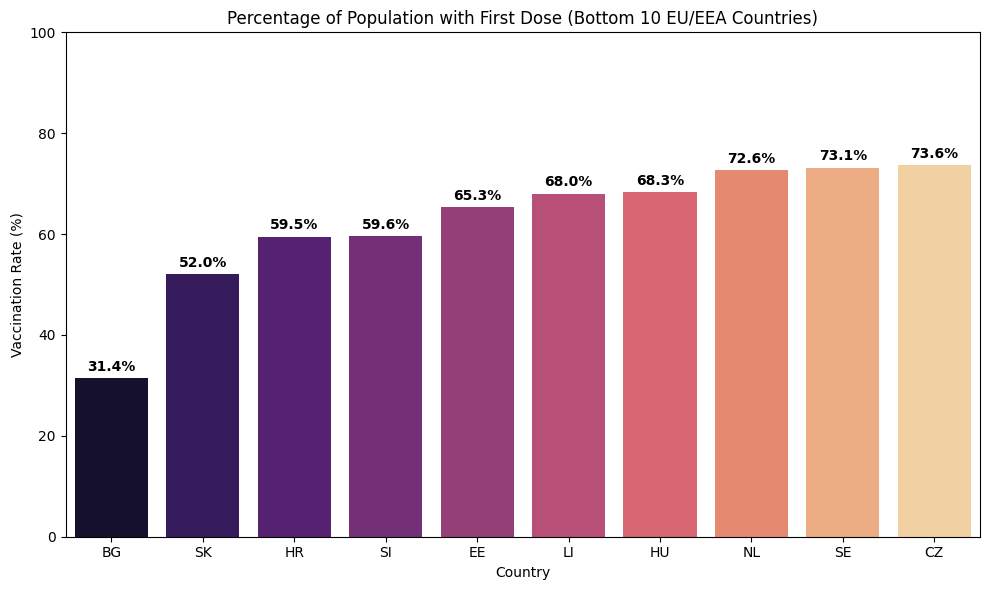

In [88]:
# =====================================================================
# VACCINATION UPTAKE AS A PROXY FOR SKEPTICISM
# =====================================================================

# 1. Ensure Population and FirstDose are numeric values
df_vax['Population'] = pd.to_numeric(df_vax['Population'], errors='coerce')
df_vax['FirstDose'] = pd.to_numeric(df_vax['FirstDose'], errors='coerce')

# 2. Filter out the 'ALL' target group to avoid double-counting doses
df_vax_filtered = df_vax[df_vax['TargetGroup'] != 'ALL']

# 3. Group by country to get total first doses and the population
vax_summary = df_vax_filtered.groupby('ReportingCountry').agg(
    TotalFirstDoses=('FirstDose', 'sum'),
    CountryPopulation=('Population', 'max') 
).reset_index()

# 4. Calculate the percentage of the population that received the first dose
vax_summary['Vaccinated_Percentage'] = (vax_summary['TotalFirstDoses'] / vax_summary['CountryPopulation']) * 100

# 5. MÄRK VÄL: Här sorterar vi listan från lägst till högst procent!
vax_summary = vax_summary.sort_values(by='Vaccinated_Percentage', ascending=True).dropna()

# 6. Lägg till det fullständiga namnet nu när listan är sorterad
vax_summary['FullCountryName'] = vax_summary['ReportingCountry'].map(country_names)

# 7. Print the table for the 5 least vaccinated countries
print("="*60)
print("TOP 5 LEAST VACCINATED COUNTRIES (PROXY FOR SKEPTICISM):")
print("="*60)
for rank, row in enumerate(vax_summary.head(5).itertuples(), start=1):
    print(f"{rank}. {row.FullCountryName}: {row.Vaccinated_Percentage:.1f}% of the population")
print("="*60)

# 8. Create a clean Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=vax_summary.head(10), 
    x='ReportingCountry', 
    y='Vaccinated_Percentage', 
    hue='ReportingCountry',
    palette='magma',
    legend=False
)

# Add titles and labels
plt.title('Percentage of Population with First Dose (Bottom 10 EU/EEA Countries)')
plt.ylabel('Vaccination Rate (%)')
plt.xlabel('Country')
plt.ylim(0, 100) # Set the Y-axis from 0 to 100%

# Add the actual percentage numbers on top of the bars for clarity
for index, value in enumerate(vax_summary.head(10)['Vaccinated_Percentage']):
    plt.text(index, value + 1.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Bulgaria low vaccination rate and relatively high hospilitazion rate. Same with Slovakia. For such small countries compared to the others which is big. 

Q6:

MOST VACCINATED UNDER-18 POPULATION (Top 5 Countries):
1. Finland: 48.94% of total population
2. Spain: 20.49% of total population
3. Ireland: 15.83% of total population
4. France: 13.58% of total population
5. Austria: 11.71% of total population

LEAST VACCINATED UNDER-18 POPULATION (Bottom 5 Countries):
1. Bulgaria: 0.41% of total population
2. Romania: 1.41% of total population
3. Croatia: 1.73% of total population
4. Slovenia: 2.08% of total population
5. Slovakia: 2.46% of total population


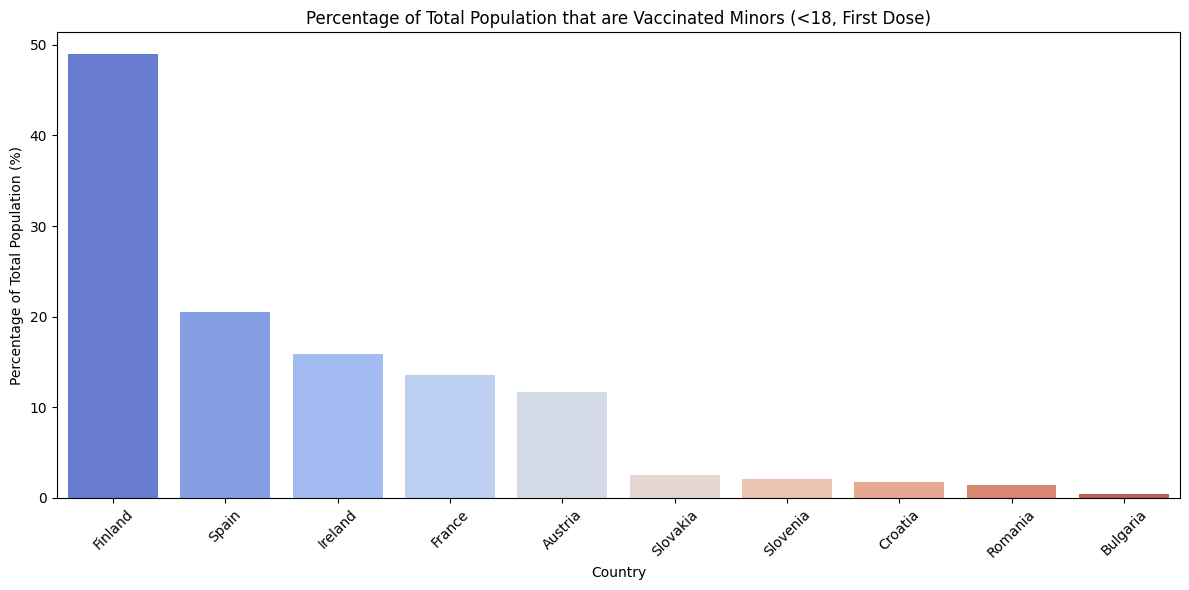

In [89]:
# QUESTION 6: VACCINATED POPULATION UNDER 18 (FIRST DOSE)
# =====================================================================

# 1. Define the Target Groups that represent people under 18
under_18_groups = ['Age<18', 'Age0_4', 'Age5_9', 'Age10_14', 'Age15_17', 'Age5_14']

# 2. Filter the dataset to only include these groups
df_under18 = df_vax[df_vax['TargetGroup'].isin(under_18_groups)].copy()

# Ensure numeric values
df_under18['FirstDose'] = pd.to_numeric(df_under18['FirstDose'], errors='coerce').fillna(0)
df_under18['Population'] = pd.to_numeric(df_under18['Population'], errors='coerce')

# 3. Group by country to sum the under-18 first doses and get the total population
u18_summary = df_under18.groupby('ReportingCountry').agg(
    U18_FirstDoses=('FirstDose', 'sum'),
    TotalPopulation=('Population', 'max') # Total population of the country
).reset_index()

# 4. Calculate the percentage of the TOTAL population that is a vaccinated under-18 year old
u18_summary['U18_Vax_Percentage'] = (u18_summary['U18_FirstDoses'] / u18_summary['TotalPopulation']) * 100

# Map the full country names using our previously created dictionary
u18_summary['FullCountryName'] = u18_summary['ReportingCountry'].map(country_names)

# 5. Sort the data to find the most and least vaccinated
u18_sorted = u18_summary.sort_values(by='U18_Vax_Percentage', ascending=False).dropna()

# 6. Print the results clearly for the report
print("="*60)
print("MOST VACCINATED UNDER-18 POPULATION (Top 5 Countries):")
print("="*60)
for rank, row in enumerate(u18_sorted.head(5).itertuples(), start=1):
    print(f"{rank}. {row.FullCountryName}: {row.U18_Vax_Percentage:.2f}% of total population")

print("\n" + "="*60)
print("LEAST VACCINATED UNDER-18 POPULATION (Bottom 5 Countries):")
print("="*60)
# We sort ascending just for the bottom 5 printout
for rank, row in enumerate(u18_sorted.sort_values(by='U18_Vax_Percentage', ascending=True).head(5).itertuples(), start=1):
    print(f"{rank}. {row.FullCountryName}: {row.U18_Vax_Percentage:.2f}% of total population")

# 7. Optional: Visualizing the top and bottom 5
top_bottom_10 = pd.concat([u18_sorted.head(5), u18_sorted.tail(5)])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_bottom_10, 
    x='FullCountryName', 
    y='U18_Vax_Percentage', 
    hue='FullCountryName',
    palette='coolwarm',
    legend=False
)

plt.title('Percentage of Total Population that are Vaccinated Minors (<18, First Dose)')
plt.ylabel('Percentage of Total Population (%)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q7:

COUNTRIES WITH THE OLDEST VACCINATED POPULATION (SECOND DOSE):
1. Finland: 83.16% of total population
2. France: 48.72% of total population
3. Poland: 37.60% of total population
4. Portugal: 27.53% of total population
5. Italy: 27.17% of total population
6. Denmark: 25.94% of total population
7. Greece: 25.16% of total population
8. Belgium: 24.45% of total population
9. Spain: 24.40% of total population
10. Malta: 23.91% of total population


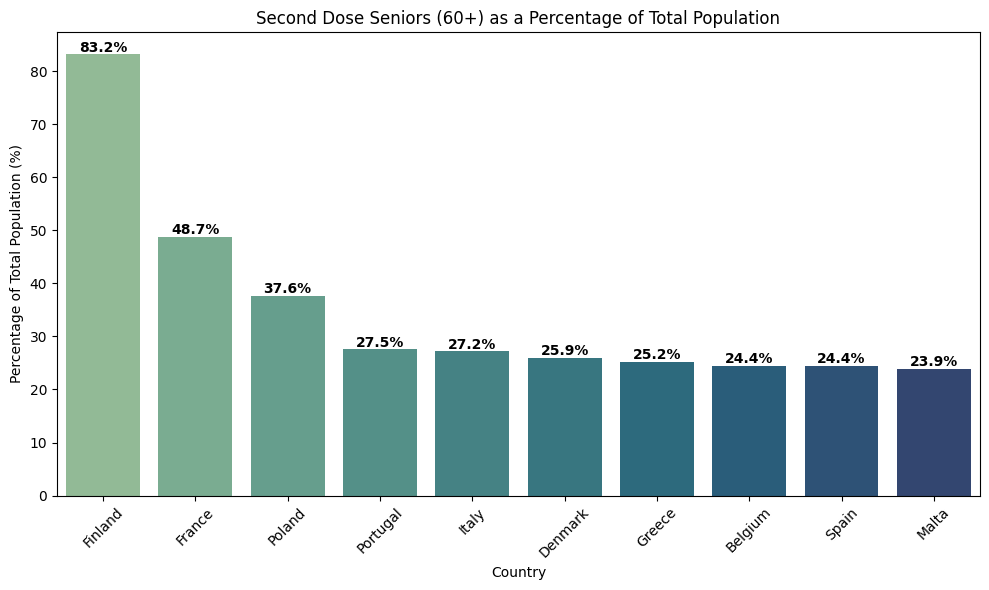

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# QUESTION 7: OLDEST VACCINATED POPULATION (SECOND DOSE)
# =====================================================================

# 1. Define the Target Groups that represent the oldest population
oldest_groups = ['Age60_69', 'Age70_79', 'Age80+']

# 2. Filter the dataset to only include these senior groups
df_seniors = df_vax[df_vax['TargetGroup'].isin(oldest_groups)].copy()

# Ensure numeric values
df_seniors['SecondDose'] = pd.to_numeric(df_seniors['SecondDose'], errors='coerce').fillna(0)
df_seniors['Population'] = pd.to_numeric(df_seniors['Population'], errors='coerce')

# 3. Group by country to sum the second doses for seniors and get total population
senior_summary = df_seniors.groupby('ReportingCountry').agg(
    Senior_SecondDoses=('SecondDose', 'sum'),
    TotalPopulation=('Population', 'max') 
).reset_index()

# 4. Calculate the percentage of the TOTAL population that are fully vaccinated seniors
senior_summary['Senior_Vax_Percentage'] = (senior_summary['Senior_SecondDoses'] / senior_summary['TotalPopulation']) * 100

# Map the full country names using our dictionary
senior_summary['FullCountryName'] = senior_summary['ReportingCountry'].map(country_names)

# 5. Sort to find the countries with the highest proportion of vaccinated seniors
senior_sorted = senior_summary.sort_values(by='Senior_Vax_Percentage', ascending=False).dropna()

# 6. Print the Top 10 results clearly
print("="*70)
print("COUNTRIES WITH THE OLDEST VACCINATED POPULATION (SECOND DOSE):")
print("="*70)
for rank, row in enumerate(senior_sorted.head(10).itertuples(), start=1):
    print(f"{rank}. {row.FullCountryName}: {row.Senior_Vax_Percentage:.2f}% of total population")
print("="*70)

# 7. Create a clean visualization for the Top 10
plt.figure(figsize=(10, 6))
sns.barplot(
    data=senior_sorted.head(10), 
    x='FullCountryName', 
    y='Senior_Vax_Percentage', 
    hue='FullCountryName',
    palette='crest', # 'crest' is a nice green/blue gradient 
    legend=False
)

plt.title('Second Dose Seniors (60+) as a Percentage of Total Population')
plt.ylabel('Percentage of Total Population (%)')
plt.xlabel('Country')
plt.xticks(rotation=45)

# Add percentage numbers on top of the bars
for index, value in enumerate(senior_sorted.head(10)['Senior_Vax_Percentage']):
    plt.text(index, value + 0.5, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Q8:

MOST AFFECTED HEALTHCARE SYSTEMS IN 2020:
1. Spain: 1,201,892 reported hospital/ICU cases
2. France: 790,739 reported hospital/ICU cases
3. Belgium: 779,292 reported hospital/ICU cases
4. Czechia: 598,132 reported hospital/ICU cases
5. Austria: 300,862 reported hospital/ICU cases
6. Slovakia: 163,188 reported hospital/ICU cases
7. Slovenia: 110,783 reported hospital/ICU cases
8. Bulgaria: 74,155 reported hospital/ICU cases
9. Lithuania: 69,795 reported hospital/ICU cases
10. Germany: 64,153 reported hospital/ICU cases

MOST AFFECTED HEALTHCARE SYSTEMS IN 2022:
1. France: 1,153,241 reported hospital/ICU cases
2. Romania: 1,057,777 reported hospital/ICU cases
3. Spain: 731,335 reported hospital/ICU cases
4. Belgium: 700,355 reported hospital/ICU cases
5. Austria: 533,322 reported hospital/ICU cases
6. Czechia: 459,434 reported hospital/ICU cases
7. Slovakia: 378,662 reported hospital/ICU cases
8. Slovenia: 95,476 reported hospital/ICU cases
9. Bulgaria: 89,263 reported hospital/ICU cases

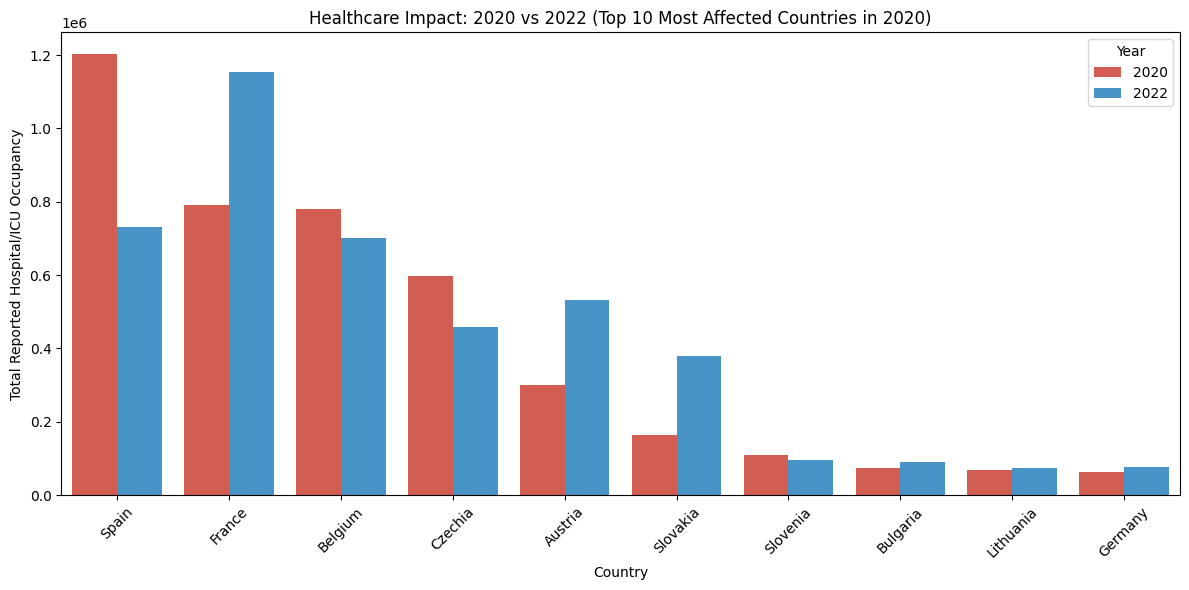

In [91]:
# QUESTION 8: HEALTHCARE IMPACT IN 2020 vs 2022

# 1. Load the dataset (if not already in memory)
df_hosp = pd.read_csv('3.COVID-19_hospital_and_ICU_admission_rates.csv')

# Ensure 'value' is numeric
df_hosp['value'] = pd.to_numeric(df_hosp['value'], errors='coerce').fillna(0)

# 2. Extract the year from the date or year_week column
# ECDC datasets usually use 'year_week' (e.g., '2020-W15') or 'date' (e.g., '2020-04-15')
if 'year_week' in df_hosp.columns:
    df_hosp['year'] = df_hosp['year_week'].astype(str).str[:4]
elif 'date' in df_hosp.columns:
    df_hosp['year'] = df_hosp['date'].astype(str).str[:4]
else:
    print("Could not find a date column!")

# 3. Filter the data for 2020 and 2022
df_2020 = df_hosp[df_hosp['year'] == '2020']
df_2022 = df_hosp[df_hosp['year'] == '2022']

# 4. Group by country and sum the values to get the total healthcare burden
hosp_2020 = df_2020.groupby('country')['value'].sum().reset_index().sort_values(by='value', ascending=False)
hosp_2022 = df_2022.groupby('country')['value'].sum().reset_index().sort_values(by='value', ascending=False)

# 5. Print the Top 10 for 2020
print("="*60)
print("MOST AFFECTED HEALTHCARE SYSTEMS IN 2020:")
print("="*60)
for rank, row in enumerate(hosp_2020.head(10).itertuples(), start=1):
    print(f"{rank}. {row.country}: {int(row.value):,} reported hospital/ICU cases")

# 6. Print the Top 10 for 2022
print("\n" + "="*60)
print("MOST AFFECTED HEALTHCARE SYSTEMS IN 2022:")
print("="*60)
for rank, row in enumerate(hosp_2022.head(10).itertuples(), start=1):
    print(f"{rank}. {row.country}: {int(row.value):,} reported hospital/ICU cases")

# 7. Visualization: Side-by-side comparison for the Top 10 most affected in 2020
# Extract the names of the top 10 countries from 2020
top_countries_2020 = hosp_2020.head(10)['country'].tolist()

# Filter both years to only include these specific countries for a direct comparison
compare_2020 = hosp_2020[hosp_2020['country'].isin(top_countries_2020)].copy()
compare_2020['Year'] = '2020'

compare_2022 = hosp_2022[hosp_2022['country'].isin(top_countries_2020)].copy()
compare_2022['Year'] = '2022'

# Combine the datasets for the plot
df_compare = pd.concat([compare_2020, compare_2022])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_compare, 
    x='country', 
    y='value', 
    hue='Year',
    palette=['#e74c3c', '#3498db'] # Red for 2020, Blue for 2022
)

plt.title('Healthcare Impact: 2020 vs 2022 (Top 10 Most Affected Countries in 2020)')
plt.ylabel('Total Reported Hospital/ICU Occupancy')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()